<a href="https://colab.research.google.com/github/sofiimasucci/F1_BigData_ETL/blob/main/03_PySpark_Cubo_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── CELDA 1: Instalar PySpark ──
!pip install pyspark findspark -q
print("PySpark instalado ✅")

PySpark instalado ✅


In [2]:
# ── CELDA 2: Iniciar SparkSession ──
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("F1_Cubo_BigData") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("SparkSession iniciada ✅")
print(f"Versión Spark: {spark.version}")

SparkSession iniciada ✅
Versión Spark: 4.0.2


In [3]:
# ── CELDA 3: Cargar tablas desde GitHub ──
import pandas as pd
import urllib.request

BASE = "https://raw.githubusercontent.com/sofiimasucci/F1_BigData_ETL/refs/heads/main/data/final/"

urllib.request.urlretrieve(BASE + "DIM_TIEMPO.csv",        "DIM_TIEMPO.csv")
urllib.request.urlretrieve(BASE + "DIM_RACES%20(1).csv",   "DIM_RACES.csv")
urllib.request.urlretrieve(BASE + "DIM_DRIVERS%20(1).csv", "DIM_DRIVERS.csv")
urllib.request.urlretrieve(BASE + "FACT_RESULTS%20(1).csv","FACT_RESULTS.csv")

DIM_TIEMPO   = spark.createDataFrame(pd.read_csv("DIM_TIEMPO.csv"))
DIM_RACES    = spark.createDataFrame(pd.read_csv("DIM_RACES.csv"))
DIM_DRIVERS  = spark.createDataFrame(pd.read_csv("DIM_DRIVERS.csv"))
FACT_RESULTS = spark.createDataFrame(pd.read_csv("FACT_RESULTS.csv"))

print("=== TABLAS CARGADAS DESDE GITHUB ===")
print(f"DIM_TIEMPO:   {DIM_TIEMPO.count():>6} filas")
print(f"DIM_RACES:    {DIM_RACES.count():>6} filas")
print(f"DIM_DRIVERS:  {DIM_DRIVERS.count():>6} filas")
print(f"FACT_RESULTS: {FACT_RESULTS.count():>6} filas")
print("\nCarga desde GitHub ✅")

=== TABLAS CARGADAS DESDE GITHUB ===
DIM_TIEMPO:     1125 filas
DIM_RACES:      1125 filas
DIM_DRIVERS:     861 filas
FACT_RESULTS:  26759 filas

Carga desde GitHub ✅


In [4]:
# ── CELDA 4: Registrar vistas SQL ──
DIM_TIEMPO.createOrReplaceTempView("DIM_TIEMPO")
DIM_RACES.createOrReplaceTempView("DIM_RACES")
DIM_DRIVERS.createOrReplaceTempView("DIM_DRIVERS")
FACT_RESULTS.createOrReplaceTempView("FACT_RESULTS")

print("Vistas SQL registradas ✅")

Vistas SQL registradas ✅


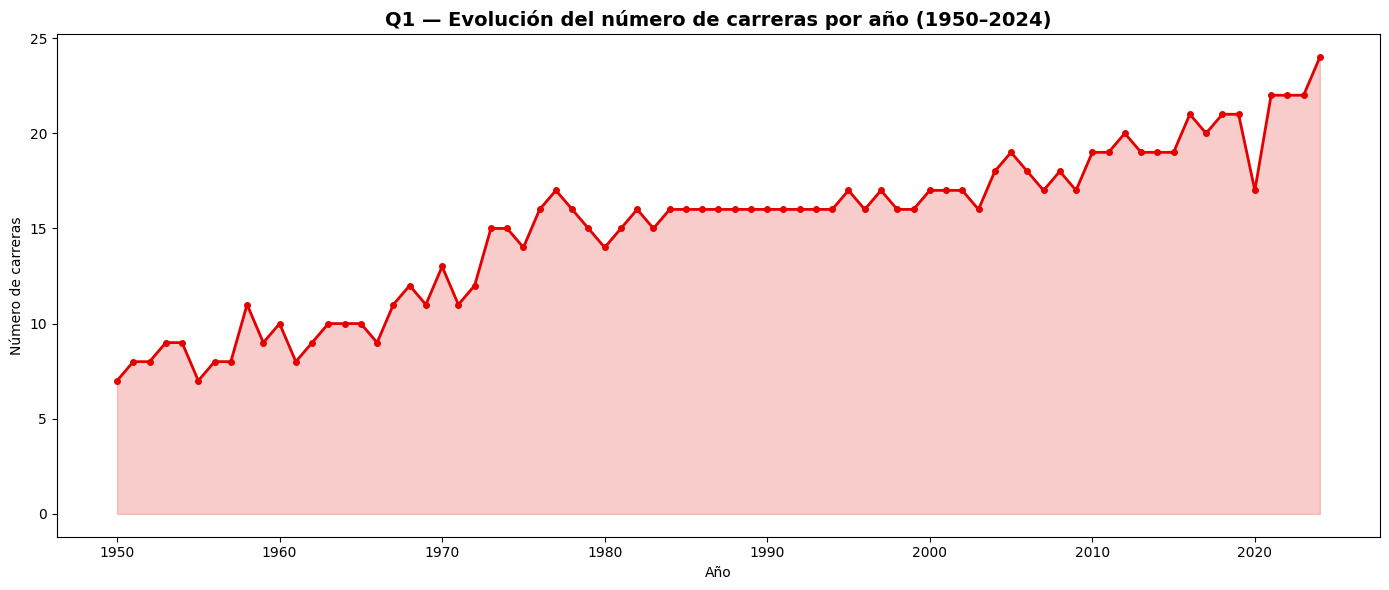

Q1 respondida ✅


In [5]:
# ── CELDA 5: Q1 — Evolución de carreras por año ──
import matplotlib.pyplot as plt

q1 = spark.sql("""
    SELECT t.anio, COUNT(r.sk_race) as num_carreras
    FROM DIM_RACES r
    JOIN DIM_TIEMPO t ON r.date = t.fecha
    GROUP BY t.anio
    ORDER BY t.anio
""").toPandas()

plt.figure(figsize=(14, 6))
plt.plot(q1['anio'], q1['num_carreras'], color='#e50000', linewidth=2, marker='o', markersize=4)
plt.fill_between(q1['anio'], q1['num_carreras'], alpha=0.2, color='#e50000')
plt.title("Q1 — Evolución del número de carreras por año (1950–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Año")
plt.ylabel("Número de carreras")
plt.tight_layout()
plt.savefig("Q1_carreras_por_año.png", dpi=150)
plt.show()
print("Q1 respondida ✅")

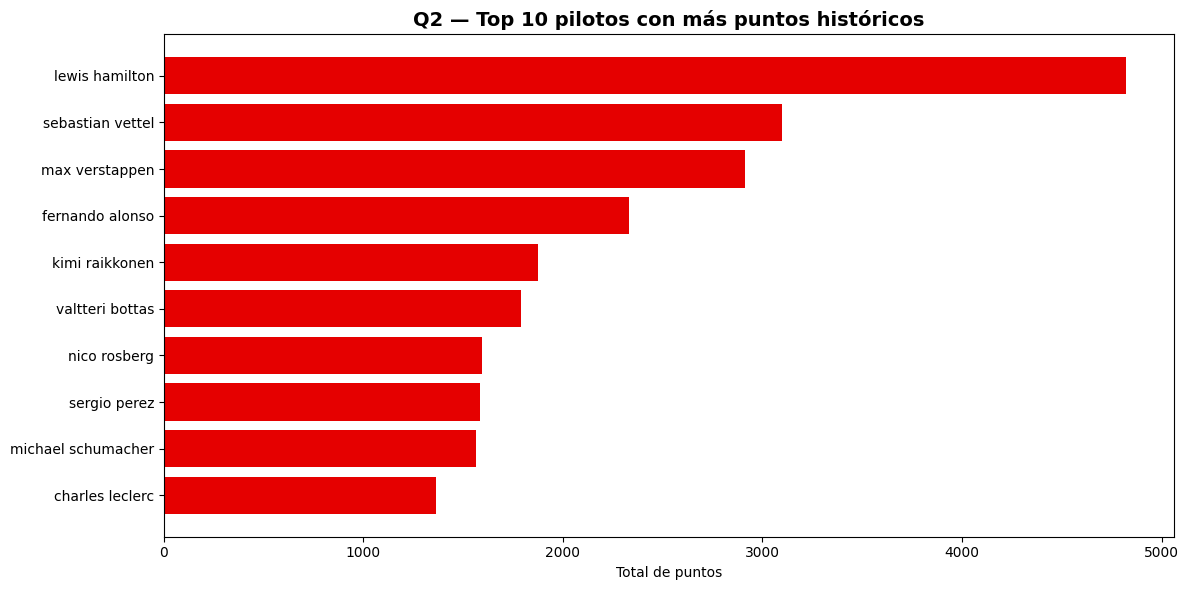

               piloto  total_puntos
0      lewis hamilton        4820.5
1    sebastian vettel        3098.0
2      max verstappen        2912.5
3     fernando alonso        2329.0
4      kimi raikkonen        1873.0
5     valtteri bottas        1788.0
6        nico rosberg        1594.5
7        sergio perez        1585.0
8  michael schumacher        1566.0
9     charles leclerc        1363.0

Q2 respondida ✅


In [6]:
# ── CELDA 6: Q2 — Top 10 pilotos con más puntos históricos ──
q2 = spark.sql("""
    SELECT d.forename || ' ' || d.surname AS piloto,
           SUM(f.points) AS total_puntos
    FROM FACT_RESULTS f
    JOIN DIM_DRIVERS d ON f.sk_driver = d.sk_driver
    GROUP BY piloto
    ORDER BY total_puntos DESC
    LIMIT 10
""").toPandas()

plt.figure(figsize=(12, 6))
plt.barh(q2['piloto'][::-1], q2['total_puntos'][::-1], color='#e50000')
plt.title("Q2 — Top 10 pilotos con más puntos históricos",
          fontsize=14, fontweight='bold')
plt.xlabel("Total de puntos")
plt.tight_layout()
plt.savefig("Q2_top10_pilotos.png", dpi=150)
plt.show()
print(q2.to_string())
print("\nQ2 respondida ✅")

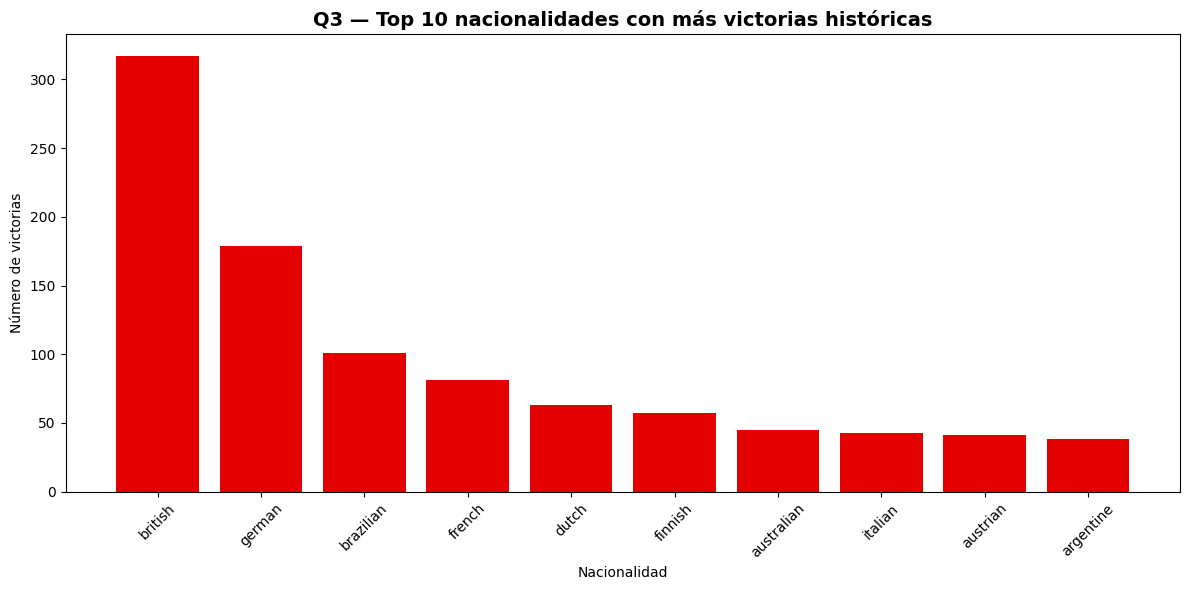

  nationality  victorias
0     british        317
1      german        179
2   brazilian        101
3      french         81
4       dutch         63
5     finnish         57
6  australian         45
7     italian         43
8    austrian         41
9   argentine         38


In [7]:
# ── CELDA 7: Q3 — Nacionalidades con más victorias ──
q3 = spark.sql("""
    SELECT d.nationality, COUNT(*) as victorias
    FROM FACT_RESULTS f
    JOIN DIM_DRIVERS d ON f.sk_driver = d.sk_driver
    WHERE f.positionOrder = 1
    GROUP BY d.nationality
    ORDER BY victorias DESC
    LIMIT 10
""").toPandas()

plt.figure(figsize=(12, 6))
plt.bar(q3['nationality'], q3['victorias'], color='#e50000')
plt.title("Q3 — Top 10 nacionalidades con más victorias históricas",
          fontsize=14, fontweight='bold')
plt.xlabel("Nacionalidad")
plt.ylabel("Número de victorias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Q3_victorias_nacionalidad.png", dpi=150)
plt.show()
print(q3.to_string())

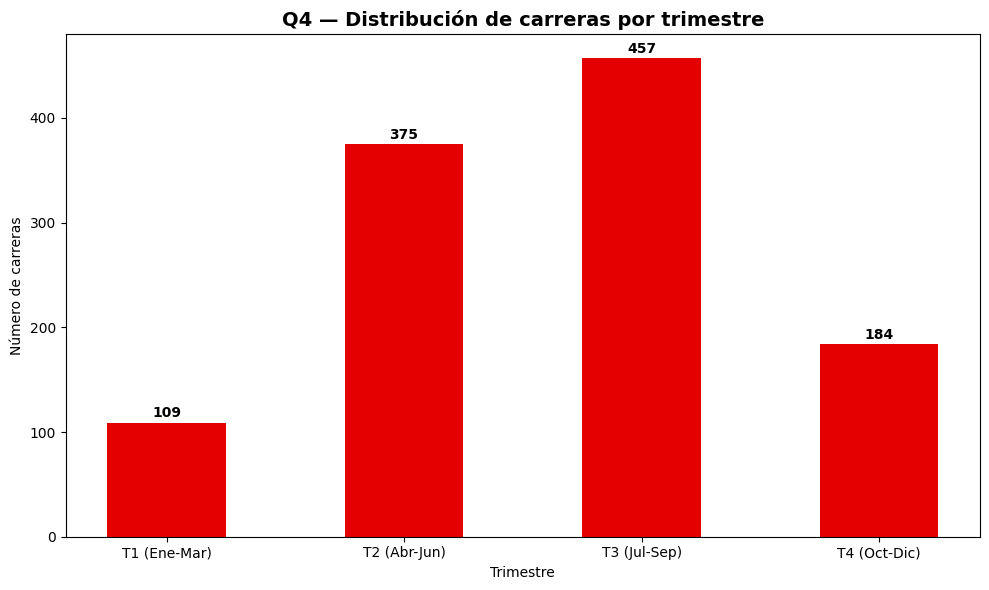

      trimestre  num_carreras
0  T1 (Ene-Mar)           109
1  T2 (Abr-Jun)           375
2  T3 (Jul-Sep)           457
3  T4 (Oct-Dic)           184

Q4 respondida ✅


In [9]:
# ── CELDA 8: Q4 — Carreras por trimestre ──
q4 = spark.sql("""
    SELECT t.trimestre, COUNT(*) as num_carreras
    FROM DIM_RACES r
    JOIN DIM_TIEMPO t ON r.date = t.fecha
    GROUP BY t.trimestre
    ORDER BY t.trimestre
""").toPandas()

q4['trimestre'] = q4['trimestre'].map({
    1: 'T1 (Ene-Mar)', 2: 'T2 (Abr-Jun)',
    3: 'T3 (Jul-Sep)', 4: 'T4 (Oct-Dic)'
})

plt.figure(figsize=(10, 6))
plt.bar(q4['trimestre'], q4['num_carreras'], color='#e50000', width=0.5)
plt.title("Q4 — Distribución de carreras por trimestre",
          fontsize=14, fontweight='bold')
plt.xlabel("Trimestre")
plt.ylabel("Número de carreras")
for i, v in enumerate(q4['num_carreras']):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("Q4_carreras_trimestre.png", dpi=150)
plt.show()
print(q4.to_string())
print("\nQ4 respondida ✅")

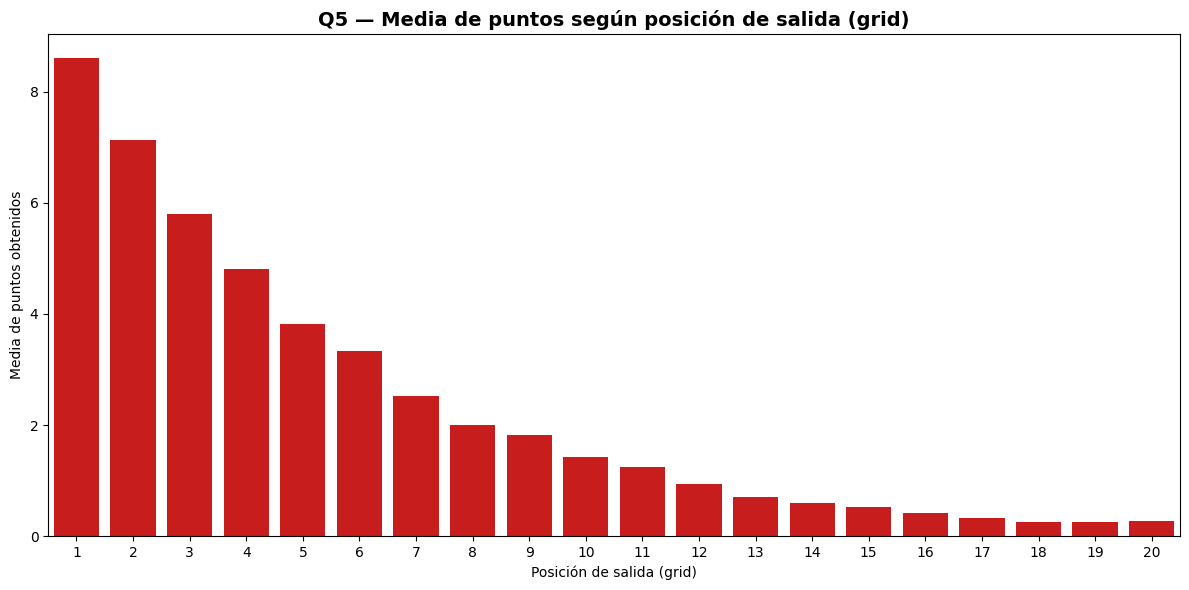

    grid  media_puntos
0      1          8.60
1      2          7.13
2      3          5.80
3      4          4.81
4      5          3.81
5      6          3.33
6      7          2.53
7      8          2.01
8      9          1.83
9     10          1.42
10    11          1.24
11    12          0.94
12    13          0.71
13    14          0.60
14    15          0.52
15    16          0.42
16    17          0.32
17    18          0.25
18    19          0.26
19    20          0.27

Q5 respondida ✅


In [10]:
# ── CELDA 9: Q5 — Relación entre grid y puntos ──
import seaborn as sns

q5 = spark.sql("""
    SELECT grid, ROUND(AVG(points), 2) as media_puntos
    FROM FACT_RESULTS
    WHERE grid > 0 AND grid <= 20
    GROUP BY grid
    ORDER BY grid
""").toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(data=q5, x='grid', y='media_puntos', color='#e50000')
plt.title("Q5 — Media de puntos según posición de salida (grid)",
          fontsize=14, fontweight='bold')
plt.xlabel("Posición de salida (grid)")
plt.ylabel("Media de puntos obtenidos")
plt.tight_layout()
plt.savefig("Q5_grid_vs_puntos.png", dpi=150)
plt.show()
print(q5.to_string())
print("\nQ5 respondida ✅")